## Predict Tesla Stock Prices using Prophet Model

In [1]:
# Get the necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from prophet import Prophet

In [15]:
# Download the data
data = yf.download('TSLA', start='2010-06-29', end='2026-04-29')
data.head()

/tmp/ipykernel_19991/4258420868.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download('TSLA', start='2010-06-29', end='2026-04-29')
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2010-06-29,1.592667,1.666667,1.169333,1.266667,281494500
2010-06-30,1.588667,2.028000,1.553333,1.719333,257806500
2010-07-01,1.464000,1.728000,1.351333,1.666667,123282000
2010-07-02,1.280000,1.540000,1.247333,1.533333,77097000
2010-07-06,1.074000,1.333333,1.055333,1.333333,103003500


In [16]:
data = data.droplevel(1, axis=1)

In [17]:
data

Price,Close,High,Low,Open,Volume
Date,,,,,
2010-06-29,1.592667,1.666667,1.169333,1.266667,281494500
2010-06-30,1.588667,2.028000,1.553333,1.719333,257806500
2010-07-01,1.464000,1.728000,1.351333,1.666667,123282000
2010-07-02,1.280000,1.540000,1.247333,1.533333,77097000
2010-07-06,1.074000,1.333333,1.055333,1.333333,103003500
...,...,...,...,...,...
2026-04-22,387.510010,393.010010,385.299988,387.570007,62362800
2026-04-23,373.720001,386.000000,368.390015,375.279999,93969500
2026-04-24,376.299988,382.760010,370.730011,373.500000,62893300


In [18]:
data = data.reset_index()

In [19]:
# Prepare the data for Prophet
df = data[['Date', 'Close']].copy()

In [20]:
df.columns = ['ds', 'y']

In [21]:
df

,ds,y
0,2010-06-29,1.592667
1,2010-06-30,1.588667
2,2010-07-01,1.464000
3,2010-07-02,1.280000
4,2010-07-06,1.074000
...,...,...
3977,2026-04-22,387.510010
3978,2026-04-23,373.720001
3979,2026-04-24,376.299988
3980,2026-04-27,378.670013


In [22]:
# Create the training data (by holding out on the last 5 days) and test data (contain the last 5 rows of data)
train_df = df.iloc[:-5, :]  # Get everything from the dataset except the last 5 rows of data
test_df = df.iloc[-5:]  # Get the last 5 days or rows of the dataset

print("Training Range:", train_df.ds.min(), 'to', train_df.ds.max())
print('Testing Range:', test_df.ds.min(), 'to', test_df.ds.max())

Training Range: 2010-06-29 00:00:00 to 2026-04-21 00:00:00
Testing Range: 2026-04-22 00:00:00 to 2026-04-28 00:00:00


In [23]:
# Create and train the Prophet model
m = Prophet(daily_seasonality=True) # Creating the model
m.fit(train_df) # Training the model

21:01:01 - cmdstanpy - INFO - Chain [1] start processing
21:01:04 - cmdstanpy - INFO - Chain [1] done processing


In [24]:
# Create a future dataframe for 5 business days (exclude weekends)
future = m.make_future_dataframe(periods=5, freq='B')
forecast = m.predict(future)

In [26]:
# Filter forecast to ONLY the actual training days in the test_df data set
pred = forecast[forecast['ds'].isin(test_df['ds'])][['ds', 'yhat', 'yhat_lower', 'yhat_upper']]
pred

,ds,yhat,yhat_lower,yhat_upper
3977,2026-04-22,394.376935,354.787997,429.679968
3978,2026-04-23,393.766761,356.561303,433.871249
3979,2026-04-24,394.262080,358.393121,434.405984
3980,2026-04-27,395.625654,359.007927,429.438671
3981,2026-04-28,395.468644,357.022317,430.048857


In [27]:
# Merge actual prices with the predicted price
comparison = test_df.merge(pred, on='ds')
print('\nActual vs Predicted:')
print(comparison)


Actual vs Predicted:
          ds           y        yhat  yhat_lower  yhat_upper
0 2026-04-22  387.510010  394.376935  354.787997  429.679968
1 2026-04-23  373.720001  393.766761  356.561303  433.871249
2 2026-04-24  376.299988  394.262080  358.393121  434.405984
3 2026-04-27  378.670013  395.625654  359.007927  429.438671
4 2026-04-28  376.019989  395.468644  357.022317  430.048857


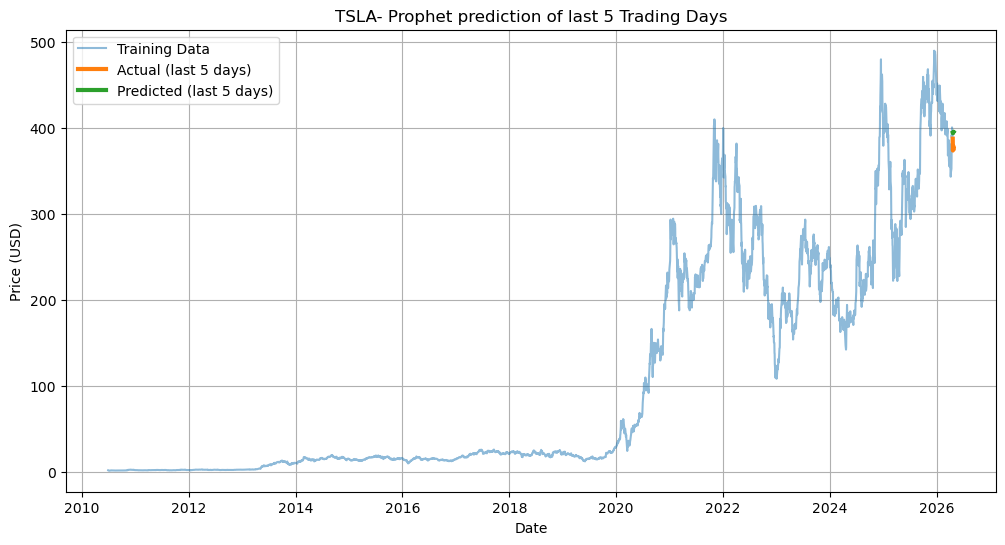

In [29]:
# Plot the actual vs predicted
plt.figure(figsize=(12,6))
plt.plot(train_df.ds, train_df.y, label='Training Data', alpha=0.5)
plt.plot(test_df.ds, test_df.y, label='Actual (last 5 days)', linewidth=3)
plt.plot(pred.ds, pred.yhat, label='Predicted (last 5 days)', linewidth=3)
plt.title('TSLA- Prophet prediction of last 5 Trading Days')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()